## Wellcome to my Notebook

Tasks to Perform

You are required to perform the following tasks using the provided dataset:

Explore the Data:
Read the dataset.
Understand each feature and document their details.
Explore the dataset information, descriptive statistics, and identify columns with categorical and numeric values.
Data Cleaning:
Delete redundant columns, if any.
Rename the columns for clarity, if necessary.
Remove duplicate rows, if any.
Clean individual columns as needed.
Remove NaN (missing) values from the dataset.
Check for Additional Transformations:
Perform any further transformations or data manipulations deemed necessary for analysis.
Please refer to the Zomato images provided within the dataset for additional context and visual references.

The analysis of this real-world problem statement will provide you with hands-on experience in data analysis and an understanding of how to approach and draw insights from such data

## Library and Dataset importing Part

In [1]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
zomato_data = pd.read_csv("/kaggle/input/zomato-restaurants-dataset-for-metropolitan-areas/zomato_dataset.csv")
zomato_data

,Restaurant Name,Dining Rating,Delivery Rating,Dining Votes,Delivery Votes,Cuisine,Place Name,City,Item Name,Best Seller,Votes,Prices
0,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Platter Kebab Combo,BESTSELLER,84,249.0
1,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken Rumali Shawarma,BESTSELLER,45,129.0
2,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken Tandoori Salad,NaN,39,189.0
3,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken BBQ Salad,BESTSELLER,43,189.0
4,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Special Doner Wrap Combo,MUST TRY,31,205.0
...,...,...,...,...,...,...,...,...,...,...,...,...
123652,Ariena Boutique Hotel,3.9,4.2,13,523,Pizza,Purena,Raipur,Murgh Reshmi Kebab,NaN,0,525.0
123653,Ariena Boutique Hotel,3.9,4.2,13,523,Pizza,Purena,Raipur,Murgh Large Tikka,NaN,0,525.0
123654,Ariena Boutique Hotel,3.9,4.2,13,523,Pizza,Purena,Raipur,Murgh Chukandri Tikka,NaN,0,525.0
123655,Ariena Boutique Hotel,3.9,4.2,13,523,Pizza,Purena,Raipur,Murgh Golden Kebab,NaN,0,525.0


## Data Cleaning and Analysis Part

In [3]:
zomato_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123657 entries, 0 to 123656
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Restaurant Name  123657 non-null  object 
 1   Dining Rating    91421 non-null   float64
 2   Delivery Rating  122377 non-null  float64
 3   Dining Votes     123657 non-null  int64  
 4   Delivery Votes   123657 non-null  int64  
 5   Cuisine          123657 non-null  object 
 6   Place Name       123657 non-null  object 
 7   City             123657 non-null  object 
 8   Item Name        123657 non-null  object 
 9   Best Seller      27942 non-null   object 
 10  Votes            123657 non-null  int64  
 11  Prices           123657 non-null  float64
dtypes: float64(3), int64(3), object(6)
memory usage: 11.3+ MB


In [4]:
zomato_data.describe()

,Dining Rating,Delivery Rating,Dining Votes,Delivery Votes,Votes,Prices
count,91421.000000,122377.000000,123657.000000,123657.000000,123657.000000,123657.000000
mean,3.822264,3.963184,152.729858,115.763725,24.666772,241.378399
std,0.408693,0.245900,232.214061,243.970828,125.236009,192.830713
min,2.500000,2.500000,0.000000,0.000000,0.000000,0.950000
25%,3.600000,3.800000,0.000000,0.000000,0.000000,130.000000
50%,3.900000,4.000000,30.000000,0.000000,0.000000,208.570000
75%,4.100000,4.100000,217.000000,23.000000,15.000000,299.000000
max,4.800000,4.600000,997.000000,983.000000,9750.000000,12024.000000


In [5]:
zomato_data.isnull().sum()

Restaurant Name        0
Dining Rating      32236
Delivery Rating     1280
Dining Votes           0
Delivery Votes         0
Cuisine                0
Place Name             0
City                   0
Item Name              0
Best Seller        95715
Votes                  0
Prices                 0
dtype: int64

### Null value handling

In [6]:
zomato_data['Dining Rating'].fillna(zomato_data['Dining Rating'].mean(),inplace=True)
zomato_data['Delivery Rating'].fillna(zomato_data['Delivery Rating'].mean(), inplace=True)
zomato_data['Dining Votes'].fillna(zomato_data['Dining Votes'].mean(), inplace=True)
zomato_data['Delivery Votes'].fillna(zomato_data['Delivery Votes'].mean(), inplace=True)
zomato_data['Best Seller'].fillna(zomato_data['Best Seller'].mode()[0], inplace=True)

In [7]:
zomato_data.isnull().sum()

Restaurant Name    0
Dining Rating      0
Delivery Rating    0
Dining Votes       0
Delivery Votes     0
Cuisine            0
Place Name         0
City               0
Item Name          0
Best Seller        0
Votes              0
Prices             0
dtype: int64

### Average Rating of Dining

In [8]:
zomato_data['Dining Rating'].values.sum()/len(zomato_data['Dining Rating'])

3.8222640312400875

### Average Rating of Delivery

In [9]:
zomato_data['Delivery Rating'].values.sum()/len(zomato_data['Delivery Rating'])

3.9631842584799437

### 10 highest number of Restaurant

In [10]:
res=zomato_data['Restaurant Name'].value_counts().head(10)
px.bar(res)

### Top City with highest number of Restaurants

In [11]:
Top_cities = zomato_data['City'].value_counts().head(10)
px.bar(Top_cities)

### Top 10 Restaurant by Dining Rating

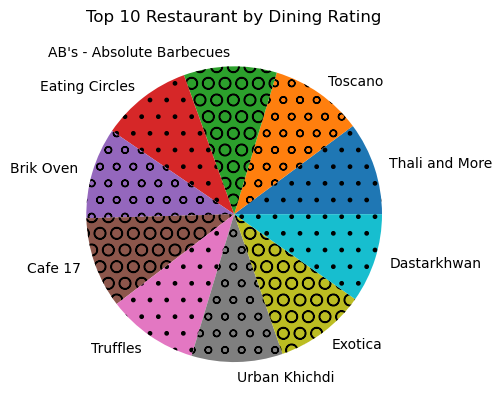

In [12]:
rest_dining= zomato_data.groupby('Restaurant Name')['Dining Rating'].mean().reset_index()
sorted_dining= rest_dining.sort_values('Dining Rating',ascending=False).head(10)

restaurant= sorted_dining['Restaurant Name']
ratings= sorted_dining['Dining Rating']


plt.pie(ratings, labels= restaurant, hatch=['.','o','O'])
plt.title('Top 10 Restaurant by Dining Rating')
plt.show()

### Top Restaurant by Delivery Rating

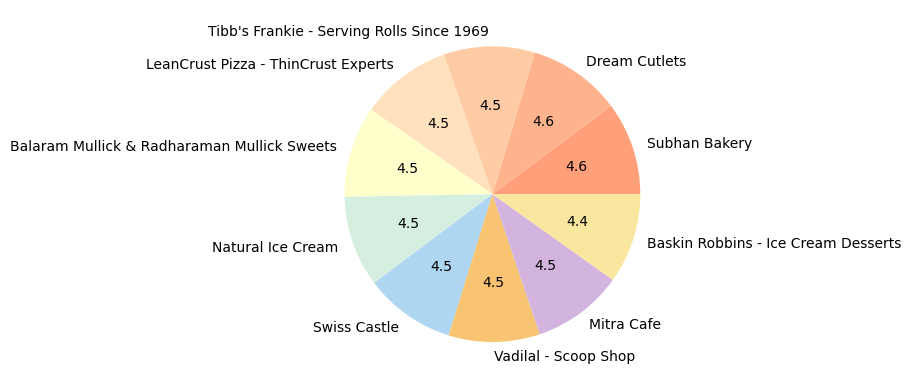

In [13]:
rest_delivery= zomato_data.groupby('Restaurant Name')['Delivery Rating'].mean().reset_index()
sorted_delivery= rest_delivery.sort_values('Delivery Rating', ascending=False).head(10)

rest_name=sorted_delivery['Restaurant Name']
delivery_rating=sorted_delivery['Delivery Rating']

colors = ['#FFA07A', '#FFB38D', '#FFCBA4', '#FFE1BD', '#FFFFCC', '#D4EFDF', '#AED6F1', '#F8C471', '#D2B4DE', '#F9E79F']

_,_,autotexts=plt.pie(delivery_rating, labels=rest_name, colors= colors, autopct='')

for i, delivery_rating in enumerate(delivery_rating):
    autotexts[i].set_text(f'{delivery_rating:.1f}')
    
plt.show()

### Common & Popular Dishes

In [14]:
dishes= zomato_data['Item Name'].value_counts().head(20)
a=pd.DataFrame(dishes)
print('Popular Dishes :- \n\n',a)

Popular Dishes :- 

                       Item Name
Veg Fried Rice              322
Paneer Butter Masala        319
Chicken Fried Rice          278
Jeera Rice                  231
Chicken Biryani             226
French Fries                211
Butter Naan                 198
Egg Fried Rice              197
Veg Biryani                 188
Chicken 65                  181
Dal Fry                     172
Egg Biryani                 172
Dal Tadka                   166
Mutton Biryani              154
Butter Chicken              149
Margherita Pizza            146
Paneer Tikka Masala         140
Cold Coffee                 137
Tandoori Chicken            135
Paneer 65                   133


### Top 10 Dining Place for any specific item

In [15]:
item_df= zomato_data[zomato_data['Item Name'] == 'Chicken Biryani'] # here just change the item name instead 'Chicken Biryani'

top_for_biryani = item_df.groupby('Place Name')['Dining Rating'].mean().head(10)

px.bar(top_for_biryani)

### Dining Rating vs Price

#### Low Price item has the High Rating. That mean People eats the dishes between 0-4000 Rs.

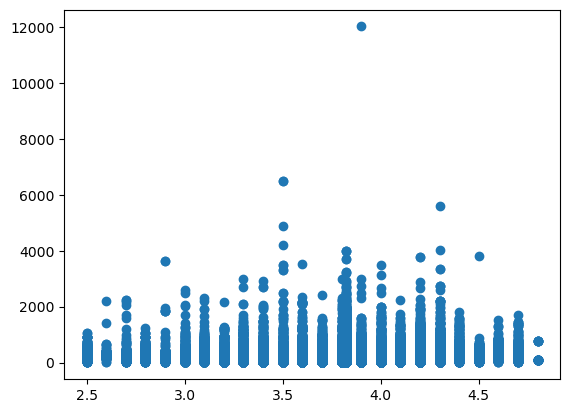

In [16]:
plt.scatter(zomato_data['Dining Rating'], zomato_data['Prices'])

In [17]:
price= zomato_data['Prices']

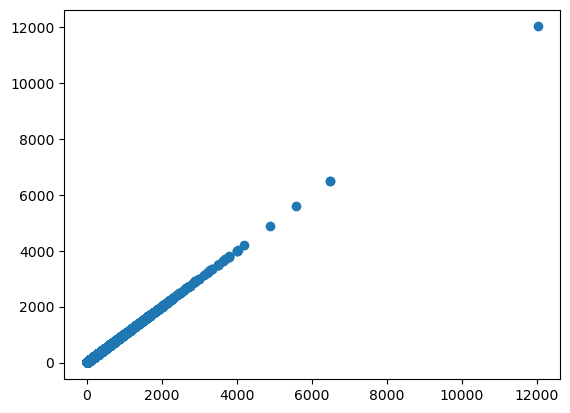

In [18]:
plt.scatter(price,price)

## If you learned any thing Please Upvote this notebook. And Share your Comments